<a href="https://colab.research.google.com/github/romenmeitei/Validation-of-docking-pose-against-grid-size-effects/blob/main/Validation_of_docking_pose_against_grid_size_effects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install biopython numpy pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.0 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving 6dcl_prpared.pdbqt to 6dcl_prpared.pdbqt
Saving 161671_large_grid.pdbqt to 161671_large_grid.pdbqt
Saving 161671_Site_focused_grid.pdbqt to 161671_Site_focused_grid.pdbqt
Saving 5271805_large_grid.pdbqt to 5271805_large_grid.pdbqt
Saving 5271805_Site_focused_grid.pdbqt to 5271805_Site_focused_grid.pdbqt
Saving 5280805_large_grid.pdbqt to 5280805_large_grid.pdbqt
Saving 5280805_Site_focused_grid.pdbqt to 5280805_Site_focused_grid.pdbqt
Saving 5281600_large_grid.pdbqt to 5281600_large_grid.pdbqt
Saving 5281600_Site_focused_grid.pdbqt to 5281600_Site_focused_grid.pdbqt


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

In [24]:
def parse_pdbqt(file):
    models = []
    current_model = []

    with open(file, 'r') as f:
        for line in f:
            if line.startswith("MODEL"):
                current_model = []
            elif line.startswith("ATOM") or line.startswith("HETATM"):
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                current_model.append([x, y, z])
            elif line.startswith("ENDMDL"):
                models.append(np.array(current_model))
    return models

In [25]:
def get_pocket_atoms(pdbqt_file, res_start=88, res_end=101):
    coords = []
    with open(pdbqt_file, 'r') as f:
        for line in f:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                res_id = int(line[22:26])
                if res_start <= res_id <= res_end:
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    coords.append([x, y, z])
    return np.array(coords)

pocket_coords = get_pocket_atoms("6dcl_prpared.pdbqt")
pocket_center = np.mean(pocket_coords, axis=0)

In [26]:
files_dict = {
    "Withanolide_large": "161671_large_grid.pdbqt",
    "Withanolide_focused": "161671_Site_focused_grid.pdbqt",
    "Ginkgetin_large": "5271805_large_grid.pdbqt",
    "Ginkgetin_focused": "5271805_Site_focused_grid.pdbqt",
    "Amentoflavone_large": "5281600_large_grid.pdbqt",
    "Amentoflavone_focused": "5281600_Site_focused_grid.pdbqt",
    "Rutin_large": "5280805_large_grid.pdbqt",
    "Rutin_focused": "5280805_Site_focused_grid.pdbqt"
}

In [27]:
def center_of_mass(coords):
    return np.mean(coords, axis=0)

coms = {}

for key, file in files_dict.items():
    poses = parse_pdbqt(file)
    coms[key] = np.array([center_of_mass(p) for p in poses])

In [29]:
def com_distance_to_pocket(com, pocket_center):
    return np.linalg.norm(com - pocket_center)

results_com = {}

for key, coords in coms.items():
    distances = [com_distance_to_pocket(c, pocket_center) for c in coords]
    results_com[key] = np.array(distances)

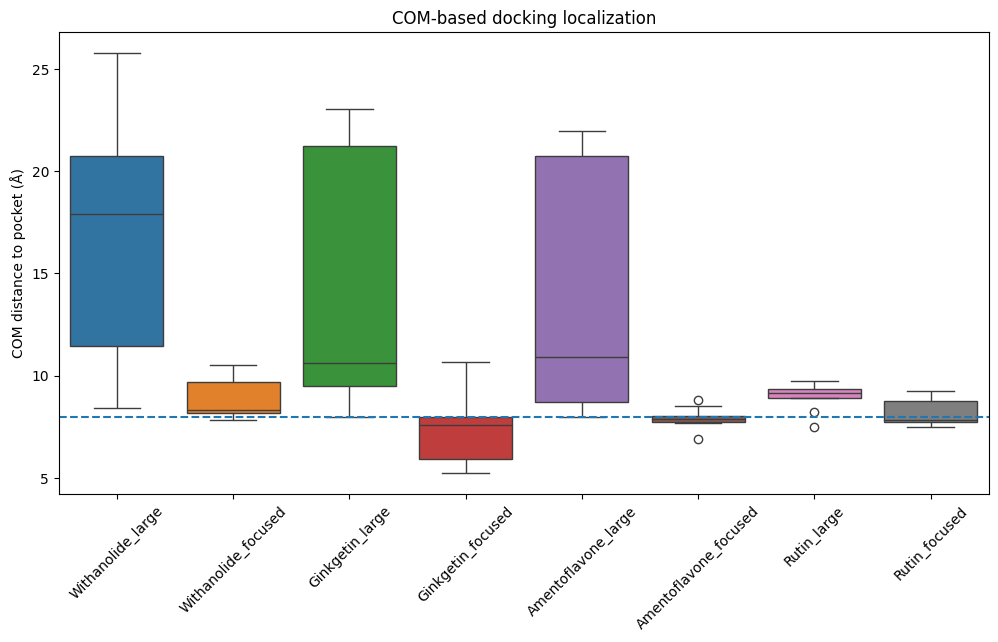

In [30]:
df_com = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in results_com.items()]))

plt.figure(figsize=(12,6))
sns.boxplot(data=df_com)
plt.axhline(8, linestyle='--')  # pocket cutoff
plt.ylabel("COM distance to pocket (Å)")
plt.xticks(rotation=45)
plt.title("COM-based docking localization")
plt.show()

In [31]:
pocket_occupancy = {}

for key, distances in results_com.items():
    percent = np.sum(distances < 8) / len(distances) * 100
    pocket_occupancy[key] = percent

pd.DataFrame.from_dict(pocket_occupancy, orient='index', columns=['% near pocket'])

,% near pocket
Withanolide_large,0.000000
Withanolide_focused,11.111111
Ginkgetin_large,11.111111
Ginkgetin_focused,77.777778
Amentoflavone_large,11.111111
Amentoflavone_focused,66.666667
Rutin_large,11.111111
Rutin_focused,55.555556


In [32]:
def filter_near_pocket(coords, pocket_center, cutoff=8):
    return np.array([c for c in coords if np.linalg.norm(c - pocket_center) < cutoff])

filtered_coms = {}

for key, coords in coms.items():
    filtered_coms[key] = filter_near_pocket(coords, pocket_center)

In [33]:
clusters = {}

for key, coords in filtered_coms.items():
    if len(coords) > 0:
        clustering = DBSCAN(eps=3.5, min_samples=2).fit(coords)
        clusters[key] = clustering.labels_
    else:
        clusters[key] = np.array([])

In [34]:
cluster_summary = {}

for key, labels in clusters.items():
    if len(labels) > 0:
        unique, counts = np.unique(labels, return_counts=True)
        cluster_summary[key] = dict(zip(unique, counts))
    else:
        cluster_summary[key] = {}

pd.DataFrame(cluster_summary).fillna(0)

,Withanolide_large,Withanolide_focused,Ginkgetin_large,Ginkgetin_focused,Amentoflavone_large,Amentoflavone_focused,Rutin_large,Rutin_focused
-1,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
0,0.0,0.0,0.0,4.0,0.0,6.0,0.0,5.0
1,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0


In [35]:
dominant_cluster_fraction = {}

for key, labels in clusters.items():
    if len(labels) > 0:
        unique, counts = np.unique(labels, return_counts=True)
        counts = dict(zip(unique, counts))

        if -1 in counts:
            del counts[-1]

        if len(counts) > 0:
            dominant = max(counts.values()) / len(labels) * 100
        else:
            dominant = 0
    else:
        dominant = 0

    dominant_cluster_fraction[key] = dominant

pd.DataFrame.from_dict(dominant_cluster_fraction, orient='index', columns=['% dominant cluster'])

,% dominant cluster
Withanolide_large,0.000000
Withanolide_focused,0.000000
Ginkgetin_large,0.000000
Ginkgetin_focused,57.142857
Amentoflavone_large,0.000000
Amentoflavone_focused,100.000000
Rutin_large,0.000000
Rutin_focused,100.000000


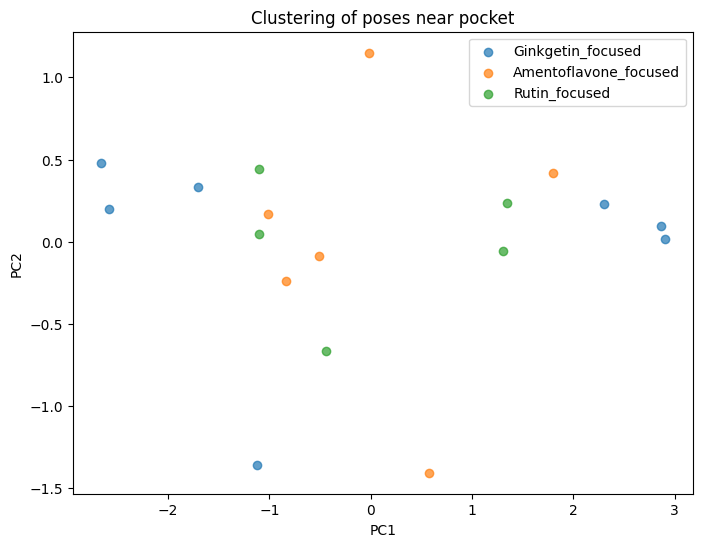

In [36]:
plt.figure(figsize=(8,6))

for key, coords in filtered_coms.items():
    if len(coords) > 1:
        pca = PCA(n_components=2)
        reduced = pca.fit_transform(coords)
        plt.scatter(reduced[:,0], reduced[:,1], label=key, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("Clustering of poses near pocket")
plt.show()

In [37]:
def contact_fraction(pose_coords, pocket_coords, cutoff=4.5):
    count = 0
    for atom in pose_coords:
        dists = np.linalg.norm(pocket_coords - atom, axis=1)
        if np.any(dists < cutoff):
            count += 1
    return count / len(pose_coords)

In [38]:
contact_results = {}

for key, file in files_dict.items():
    poses = parse_pdbqt(file)
    contacts = []

    for pose in poses:
        cf = contact_fraction(pose, pocket_coords)
        contacts.append(cf)

    contact_results[key] = np.array(contacts)

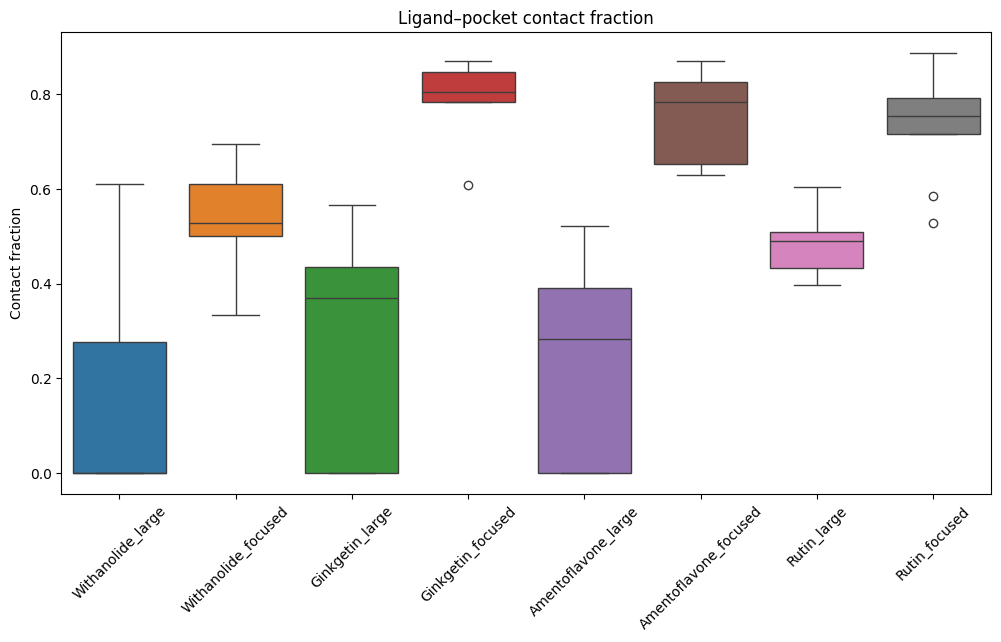

In [39]:
df_contact = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in contact_results.items()]))

plt.figure(figsize=(12,6))
sns.boxplot(data=df_contact)
plt.ylabel("Contact fraction")
plt.xticks(rotation=45)
plt.title("Ligand–pocket contact fraction")
plt.show()

In [40]:
contact_std = {}

for key, values in contact_results.items():
    contact_std[key] = np.std(values)

pd.DataFrame.from_dict(contact_std, orient='index', columns=['Contact variability'])

,Contact variability
Withanolide_large,0.232447
Withanolide_focused,0.108859
Ginkgetin_large,0.219979
Ginkgetin_focused,0.073899
Amentoflavone_large,0.196975
Amentoflavone_focused,0.089339
Rutin_large,0.070035
Rutin_focused,0.110735


In [41]:
def weighted_contact(pose_coords, pocket_coords):
    score = 0
    for atom in pose_coords:
        dists = np.linalg.norm(pocket_coords - atom, axis=1)
        score += np.sum(1 / (dists + 1e-6))
    return score / len(pose_coords)